In [1]:
# Activity: Understanding Maximum Flow Calculations
Fill me in.

UndefVarError: UndefVarError: `Fill` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

The [include command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

In [2]:
include(joinpath(@__DIR__, "Include.jl"));

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types and data used in this material. 

### Constants
Let's define some constants that will be used throughout the notebook. See the comment for a description of each constant, what it represents, its value, units, etc.

In [3]:
# We are going to plot the path through a graph, so let's provide the coordinates for each node, i.e., the layout
# This layout looks like our schematic but you can rearrange this if you want!
node_coordinates = [

    # source node (you)
    10.0 10.0 ; # 1 source node s (x,y) coordinates

    # people nodes (workers)
    11.0 11.0 ; # 2 people node (x,y) coordinates
    11.0 10.0 ; # 3 people node (x,y) coordinates
    11.0 9.0 ; # 4 people node (x,y) coordinates

    # job nodes (tasks)
    12.0 11.0 ; # 5 job node (x,y) coordinates
    12.0 10.0 ; # 6 job node (x,y) coordinates
    12.0 9.0 ; # 7 job node (x,y) coordinates
    12.0 8.0 ; # 8 job node (x,y) coordinates

    # sink nodes (targets, tasks done!)
    13.0 11.0 ; # 9 sink node t (x,y) coordinates
    13.0 10.0 ; # 10 sink node t (x,y) coordinates
    13.0 9.0 ; # 11 sink node t (x,y) coordinates
    13.0 8.0 ; # 12 sink node t (x,y) coordinates
    
    14.0 10.0 ; # 13 end node (x,y) coordinates
];

## Task 1: Build a task allocation graph model
Let's return to the task allocation problem, but with a twist. You're still node `1` (the source node, manager etc). We have a small bipartite graph setup: worker nodes connected to task nodes, where we need to allocate workers to tasks, e.g., we need to find a __flow__ through the network, and in particular we'll find the __maximum flow__.

> __Twist:__ not every worker can do every task, e.g., they don't have the proper training, or perhaps they are on vacation. Thus, in this case instead of thinking about the edge weight, let's think about maximizing the capacity of the assignment, i.e., we want every worker assigned to tasks such that we use all of our workers capacity.

The problem graph edges are stored in `data/Workers-Tasks-Bipartite.edgelist` with fields: 

> __Records__: Each record in our edgelist file has the comma separated fields: `source,` `target,` `cost,` `lb capacity,` `ub capacity`. The `source` field is the id for the source node, e.g., `1`, the `target` field is the target node id, the `cost` is the cost of assigning the source node to the target node, the `lb capacity` is the lower bound capacity for the edge, and the `ub capacity` is the upper bound capacity for the edge.

In this activity, we'll ignore the edge weight (set to `1`), and instead will focus on the capacity constraints. Ok, so now let's setup our edge parser __callback function__:

In [4]:
"""
    function edgerecordparser(record::String, delim::Char=',') -> Tuple{Int, Int, Float64} | Nothing

This method is called to parse a single edge record from the edgelist file. It gets called once for each record in the file. 
The function splits the record into fields based on the specified delimiter and extracts the source node, target node, and cost (weight) of the edge. 
It returns a tuple containing these values. If the record does not have the expected number of fields, it returns `nothing`.

### Arguments
- `record`: The edge record string to parse.
- `delim`: The delimiter used to split the record.

### Returns
- A tuple containing the source node, target node, and cost of the edge, or `nothing` if the record is invalid.
"""
function edgerecordparser(record::String, delim::Char=',')
    
    # record (five fields)
    # source, target, cost, lb, ub

    fields = split(record, delim) # this assumes a record of the form "source,target,weight"
    if length(fields) < 5 # we have 5 fields
        return nothing
    end

    # get my data from the line -
    source = parse(Int, fields[1]) # source id
    target = parse(Int, fields[2]) # target id
    cost = parse(Float64, fields[3]) # edge weight
    l = parse(Float64, fields[4]) # lower bound capacity
    u = parse(Float64, fields[5]) # upper bound capacity

    # return a tuple -
    return (source, target, cost, l, u)
end;

Next, let's set the path to the edge list file in the `path_to_edge_file::String` variable:

In [5]:
path_to_edge_file = joinpath(_PATH_TO_DATA, "Workers-Tasks-Bipartite.edgelist"); # this points to the graph shown above

Next, construct a dictionary [of `MyConstrainedGraphEdgeModel` instances](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/types/#VLDataScienceMachineLearningPackage.MyConstrainedGraphEdgeModel) which stores the data for the edges. Let's save our edge models in the `myedgemodels::Dict{Int64, MyConstrainedGraphEdgeModel}` dictionary.

The keys in the edge dictionary will be the edge ids (which we can assume are unique), and the values will be the corresponding `MyConstrainedGraphEdgeModel` instances. Here, we've used the line index in the edgefile as the edge id.

In [6]:
myedgemodels = MyConstrainedGraphEdgeModels(path_to_edge_file, edgerecordparser, delim=',', comment='#')

Dict{Int64, MyConstrainedGraphEdgeModel} with 23 entries:
  5  => MyConstrainedGraphEdgeModel(5, 7, 11, 1.0, 0.0, 1.0)
  16 => MyConstrainedGraphEdgeModel(16, 3, 6, 1.0, 0.0, 1.0)
  20 => MyConstrainedGraphEdgeModel(20, 4, 6, 1.0, 0.0, 1.0)
  12 => MyConstrainedGraphEdgeModel(12, 2, 6, 1.0, 0.0, 1.0)
  8  => MyConstrainedGraphEdgeModel(8, 10, 13, 1.0, 0.0, 1.0)
  17 => MyConstrainedGraphEdgeModel(17, 3, 7, 1.0, 0.0, 1.0)
  1  => MyConstrainedGraphEdgeModel(1, 1, 3, 1.0, 0.0, 1.0)
  19 => MyConstrainedGraphEdgeModel(19, 4, 5, 1.0, 0.0, 1.0)
  0  => MyConstrainedGraphEdgeModel(0, 1, 2, 1.0, 0.0, 1.0)
  22 => MyConstrainedGraphEdgeModel(22, 4, 8, 1.0, 0.0, 1.0)
  6  => MyConstrainedGraphEdgeModel(6, 8, 12, 1.0, 0.0, 1.0)
  11 => MyConstrainedGraphEdgeModel(11, 2, 5, 1.0, 0.0, 1.0)
  9  => MyConstrainedGraphEdgeModel(9, 11, 13, 1.0, 0.0, 1.0)
  14 => MyConstrainedGraphEdgeModel(14, 2, 8, 1.0, 0.0, 1.0)
  3  => MyConstrainedGraphEdgeModel(3, 5, 9, 1.0, 0.0, 1.0)
  7  => MyConstrainedGraphEd

Finally, we can build a graph instance. Since this is a directed graph, we'll construct [a `MyDirectedBipartiteGraphModel` instance](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/types/#VLDataScienceMachineLearningPackage.MyDirectedBipartiteGraphModel) using [a `build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/#VLDataScienceMachineLearningPackage.build). Let's save our graph model in the `directedgraphmodel::MyDirectedBipartiteGraphModel` variable.

In [7]:
myedgemodels[1] |> m-> typeof(m) |> T -> fieldnames(T)

(:id, :source, :target, :weight, :lower, :upper)

In [8]:
directedgraphmodel = let

    # initialize -
    s = 1; # what is the source node
    t = 13; # what is the sink node

    # call the build method to create the graph model
    model = build(MyDirectedBipartiteGraphModel, (
        s = s, # source index
        t = t, # sink index
        edges = myedgemodels
    ));

    
    model # return the model 
end;

__Hmmm__. What's in [a `MyDirectedBipartiteGraphModel` object](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/types/#VLDataScienceMachineLearningPackage.MySimpleDirectedGraphModel)? We can always answer these types of questions by examining the fields of the object Type [using the `typeof(...)` function](https://docs.julialang.org/en/v1/base/base/#Core.typeof) in combination with [the `fieldnames(...)` function](https://docs.julialang.org/en/v1/base/base/#Base.fieldnames).

> __Why do we inspect the fields of a Type?__ We need to get the type of the instance we want to inspect because fields are associated with a type, not the instance itself. Thus, we always use `typeof(...)` to get the type, and then `fieldnames(...)` to get the fields of that type.

Ok, so what is contained in a directed graph model:

In [9]:
typeof(directedgraphmodel) |> T -> fieldnames(T) # We get the type T, then we get the field names of T

(:nodes, :edges, :children, :edgesinverse, :left, :right, :source, :sink, :capacity)

Fill me in

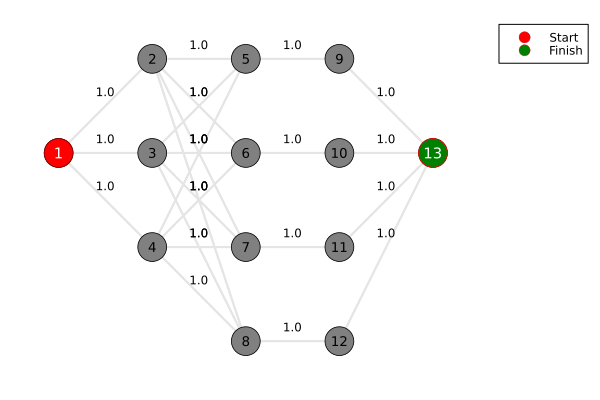

In [10]:
let

    # initialize -
    base_graphmodel = directedgraphmodel;
    source_node = 1; # this is where we start
    target_node = 13; # this is where we want to go

    # draw -
    q = plot();
    for (k,v) ∈ base_graphmodel.edgesinverse
       
        # now, get the source,target node index for this edge
        s = v[1];
        t = v[2];
        # draw baseline edge
        plot!([node_coordinates[s,1], node_coordinates[t,1]],[node_coordinates[s,2], node_coordinates[t,2]], arrow=true, color=:gray90, lw=2, label="")
        
        # add weight annotation to edges -
        mx = (node_coordinates[s,1] + node_coordinates[t,1]) / 2
        my = (node_coordinates[s,2] + node_coordinates[t,2]) / 2
        c = round(base_graphmodel.edges[(s,t)], digits=2)
        annotate!(mx, my + 0.15, text(string(c), 8, :black))
    end
    scatter!(node_coordinates[:,1], node_coordinates[:,2], axis=nothing, border=:none, label="", c=:gray, ms=16)
    
   
    scatter!([node_coordinates[source_node,1]], [node_coordinates[source_node,2]], 
             c=:red, ms=16, markerstroke=2, markerstrokecolor=:darkred, 
             label="Start")

    scatter!([node_coordinates[target_node,1]], [node_coordinates[target_node,2]], 
             c=:green, ms=16, markerstroke=2, markerstrokecolor=:red, 
             label="Finish")

    # number the nodes -
    n_nodes = size(node_coordinates, 1)
    for i in 1:n_nodes
        x = node_coordinates[i,1]
        y = node_coordinates[i,2]
        if i == source_node || i == target_node
            # white text for the red source node
            annotate!(x, y, text(string(i), 10, :white))
        else
            # black text for other nodes
            annotate!(x, y, text(string(i), 9, :black))
        end
    end

    # set the global plot attributes
    plot!(axis=nothing, border=:none, legend=:outertopright, legendfontsize=8, 
          background_color=:white, xlim=(9.5, 14.5), ylim=(7.5, 11.5))

    current() # show the current plot
end

## Task 2: Compute the maximum flow through the network
In this task, we'll compute maximum flow through the network.

Fill me in.

In [11]:
directedgraphmodel.nodes[1]

MyGraphNodeModel(1, nothing)

In [12]:
(m,flow) = let

    # initialize -
    s = 1; # we start at node 1
    t = 13; # we end at node 13
    algorithm = FordFulkersonAlgorithm(); # which algorithm to use {FordFulkerson, EdmondsKarp}

    # call -
    m,flow = maximumflow(directedgraphmodel, directedgraphmodel.nodes[s], 
        directedgraphmodel.nodes[t], algorithm = algorithm)

    # return -
    m,flow
end;

In [13]:
m

3.0

Fill me in!

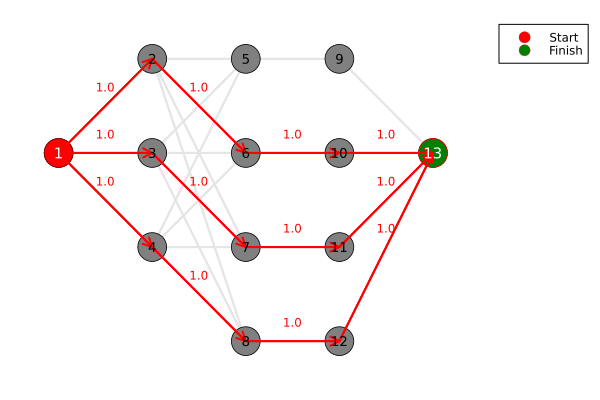

In [14]:
let

    # initialize -
    base_graphmodel = directedgraphmodel;
    source_node = 1; # this is where we start
    target_node = 13; # this is where we want to go
    path_edges = keys(flow); # this is a dictionary of (u,v) → flow_value
    capacity = base_graphmodel.capacity; # get the capacity dictionary
    flow_dictionary = flow;

    # draw -
    q = plot();
    for (k,v) ∈ base_graphmodel.edgesinverse
       
        # now, get the source,target node index for this edge
        s = v[1];
        t = v[2];
        
        # draw baseline edge
        plot!([node_coordinates[s,1], node_coordinates[t,1]],[node_coordinates[s,2], node_coordinates[t,2]], arrow=true, color=:gray90, lw=2, label="")
    end
    scatter!(node_coordinates[:,1], node_coordinates[:,2], axis=nothing, border=:none, label="", c=:gray, ms=16)
    
   
    scatter!([node_coordinates[source_node,1]], [node_coordinates[source_node,2]], 
             c=:red, ms=16, markerstroke=2, markerstrokecolor=:darkred, 
             label="Start")

    scatter!([node_coordinates[target_node,1]], [node_coordinates[target_node,2]], 
             c=:green, ms=16, markerstroke=2, markerstrokecolor=:red, 
             label="Finish")

    # plot the flow path -
    for ((s,t),flow_value) ∈ flow_dictionary
       
        plot!([node_coordinates[s,1], node_coordinates[t,1]],[node_coordinates[s,2], node_coordinates[t,2]], arrow=true, color=:red, lw=2, label="")
        
        # annotate the path-edge weight in red slightly above the red edge
        mwx = (node_coordinates[s,1] + node_coordinates[t,1]) / 2
        mwy = (node_coordinates[s,2] + node_coordinates[t,2]) / 2
        w = round(flow_dictionary[(s,t)], digits=2)
        annotate!(mwx, mwy + 0.20, text(string(w), 8, :red))
    end

    # number the nodes -
    n_nodes = size(node_coordinates, 1)
    for i in 1:n_nodes
        x = node_coordinates[i,1]
        y = node_coordinates[i,2]
        if i == source_node || i == target_node
            # white text for the red source node
            annotate!(x, y, text(string(i), 10, :white))
        else
            # black text for other nodes
            annotate!(x, y, text(string(i), 9, :black))
        end
    end

    # set the global plot attributes
    plot!(axis=nothing, border=:none, legend=:outertopright, legendfontsize=8, 
          background_color=:white, xlim=(9.5, 14.5), ylim=(7.5, 11.5))

    current() # show the current plot
end

### Analysis of the default solution
The default maximum flow matches person $2\Longrightarrow 6$, person $3\Longrightarrow 7$ and person $4\Longrightarrow 8$. Wow! That is pretty cool. But wait a minute, what about task $5$ (this does not seem to be assigned to anyone)?

> __Limited capacity?__ If we look at node $1$ (you) it has an out-degree of three, where each edge has a capacity of $1$. Thus, we can only do (at most) three tasks. Why is this the case? The flow for internal nodes, i.e., not source or sink nodes, is limited by the capacities of the edges leading into and out of them. Thus, if we give node $3$ for example, only one unit of flow, it can only do one job.

Let's play around with the capacities of the edges leaving node $1$ and see what happens. We'll update the capacities of the `directedgraphmodel::MyDirectedBipartiteGraphModel`, and then re-run the maximum flow algorithm.

In [15]:
updated_directed_graph_model = let

    # make a copy of the directed graph model
    model = deepcopy(directedgraphmodel);

    # increase the capacity of the edges leaving node 1
    for e ∈ model.edges
        if e[1] == 1
            u = model.capacity[e][2];
            model.capacity[e][2] = 2*u;
        end
    end

    model # return the updated model
end;


In [16]:
updated_directed_graph_model.capacity[(1,2)]

(0.0, 1.0)

Now, let's re-run the maximum flow algorithm on the updated directed graph model and see if the solution changes.

In [17]:
(m₁,flow₁) = let

    # initialize -
    s = 1; # we start at node 1
    t = 13; # we end at node 13
    algorithm = FordFulkersonAlgorithm(); # which algorithm to use {FordFulkerson, EdmondsKarp}

    # call -
    m,flow = maximumflow(updated_directed_graph_model, updated_directed_graph_model.nodes[s], 
        updated_directed_graph_model.nodes[t], algorithm = algorithm)

    # return -
    m,flow
end;

Fill me in.

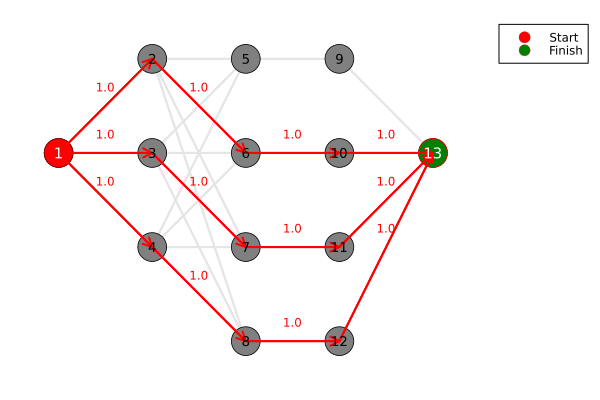

In [18]:
let

    # initialize -
    base_graphmodel = updated_directed_graph_model;
    source_node = 1; # this is where we start
    target_node = 13; # this is where we want to go
    path_edges = keys(flow); # this is a dictionary of (u,v) → flow_value
    capacity = base_graphmodel.capacity; # get the capacity dictionary
    flow_dictionary = flow₁;

    # draw -
    q = plot();
    for (k,v) ∈ base_graphmodel.edgesinverse
       
        # now, get the source,target node index for this edge
        s = v[1];
        t = v[2];
        
        # draw baseline edge
        plot!([node_coordinates[s,1], node_coordinates[t,1]],[node_coordinates[s,2], node_coordinates[t,2]], arrow=true, color=:gray90, lw=2, label="")
    end
    scatter!(node_coordinates[:,1], node_coordinates[:,2], axis=nothing, border=:none, label="", c=:gray, ms=16)
    
   
    scatter!([node_coordinates[source_node,1]], [node_coordinates[source_node,2]], 
             c=:red, ms=16, markerstroke=2, markerstrokecolor=:darkred, 
             label="Start")

    scatter!([node_coordinates[target_node,1]], [node_coordinates[target_node,2]], 
             c=:green, ms=16, markerstroke=2, markerstrokecolor=:red, 
             label="Finish")

    # plot the flow path -
    for ((s,t),flow_value) ∈ flow_dictionary
       
        plot!([node_coordinates[s,1], node_coordinates[t,1]],[node_coordinates[s,2], node_coordinates[t,2]], arrow=true, color=:red, lw=2, label="")
        
        # annotate the path-edge weight in red slightly above the red edge
        mwx = (node_coordinates[s,1] + node_coordinates[t,1]) / 2
        mwy = (node_coordinates[s,2] + node_coordinates[t,2]) / 2
        w = round(flow_dictionary[(s,t)], digits=2)
        annotate!(mwx, mwy + 0.20, text(string(w), 8, :red))
    end

    # number the nodes -
    n_nodes = size(node_coordinates, 1)
    for i in 1:n_nodes
        x = node_coordinates[i,1]
        y = node_coordinates[i,2]
        if i == source_node || i == target_node
            # white text for the red source node
            annotate!(x, y, text(string(i), 10, :white))
        else
            # black text for other nodes
            annotate!(x, y, text(string(i), 9, :black))
        end
    end

    # set the global plot attributes
    plot!(axis=nothing, border=:none, legend=:outertopright, legendfontsize=8, 
          background_color=:white, xlim=(9.5, 14.5), ylim=(7.5, 11.5))

    current() # show the current plot
end